# Spatial Autocorrelation: Global Moran's I dan Local Indicators of Spatial Association (LISA)

Notebook ini menganalisis autokorelasi spasial kemiskinan di 38 provinsi Indonesia menggunakan:
- **Global Moran's I**: mengukur seberapa terklaster data kemiskinan secara keseluruhan
- **LISA (Local Moran's I)**: mengidentifikasi klaster dan outlier spasial lokal per provinsi

Data: BPS 2021–2024, 38 provinsi Indonesia

## 0. Instalasi Library

In [4]:
# # Install library yang dibutuhkan di Google Colab
# !pip install pysal libpysal esda geopandas shapely mapclassify folium -q
# !pip install matplotlib seaborn pandas numpy scipy -q

## 1. Import Library

In [5]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

import libpysal
from libpysal.weights import Queen, KNN, lat2W
from libpysal.weights.util import fill_diagonal
import esda
from esda.moran import Moran, Moran_Local

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Semua library berhasil diimport.')
print(f'GeoPandas version: {gpd.__version__}')
print(f'libpysal version: {libpysal.__version__}')
print(f'esda version: {esda.__version__}')

## 2. Load dan Eksplorasi Data

In [6]:
df_raw = pd.read_csv('data_bps_datmin.csv')

print(f'Jumlah baris: {df_raw.shape[0]}')
print(f'Jumlah kolom: {df_raw.shape[1]}')
print(f'Provinsi unik: {df_raw["PROVINSI"].nunique()}')
print(f'Tahun: {sorted(df_raw["TAHUN"].unique())}')
print()
print(df_raw.columns.tolist())
print()
df_raw.head()

Jumlah baris: 151
Jumlah kolom: 18
Provinsi unik: 38
Tahun: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

['PROVINSI', 'TAHUN', 'APS 13-15', 'APS 16-18', 'APS 19-24', 'TPT - Februari', 'TPT - Agustus', 'TPAK - Februari', 'TPAK - Agustus', 'Garis Kemiskinan - Maret (Rp)', 'Garis Kemiskinan - September (Rp)', 'Jumlah Penduduk Miskin - Maret (ribu)', 'Jumlah Penduduk Miskin - September (ribu)', 'Persentase Penduduk Miskin - Maret', 'Persentase Penduduk Miskin - September', 'Indeks Pembangunan Manusia', 'Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi', 'Harapan Lama Sekolah (Tahun)']



,PROVINSI,TAHUN,APS 13-15,APS 16-18,APS 19-24,TPT - Februari,TPT - Agustus,TPAK - Februari,TPAK - Agustus,Garis Kemiskinan - Maret (Rp),Garis Kemiskinan - September (Rp),Jumlah Penduduk Miskin - Maret (ribu),Jumlah Penduduk Miskin - September (ribu),Persentase Penduduk Miskin - Maret,Persentase Penduduk Miskin - September,Indeks Pembangunan Manusia,Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi,Harapan Lama Sekolah (Tahun)
0,SUMATERA UTARA,2021,96.99,78.66,27.05,6.01,6.33,69.39,69.10,525756,648336,1343.86,1110.92,9.01,7.19,73.84,9.88,13.27
1,SUMATERA BARAT,2021,96.63,84.07,36.41,6.67,6.52,68.41,67.72,568703,714991,370.67,315.43,6.63,5.42,74.56,9.46,14.09
2,RIAU,2021,95.66,77.81,28.79,4.96,4.42,65.81,65.03,565937,702620,500.81,473.04,7.12,6.36,73.89,9.52,13.28
3,JAMBI,2021,96.39,72.50,24.14,4.76,5.09,67.30,67.17,506355,658100,293.86,272.70,8.09,7.26,72.62,9.03,13.04
4,SUMATERA SELATAN,2021,94.85,71.53,18.81,5.17,4.98,69.95,68.77,457455,564462,1113.76,948.84,12.84,10.51,71.83,8.78,12.54


In [7]:
desc = df_raw.describe()
print(desc.to_string())

             TAHUN   APS 13-15   APS 16-18   APS 19-24  TPT - Februari  TPT - Agustus  TPAK - Februari  TPAK - Agustus  Garis Kemiskinan - Maret (Rp)  Garis Kemiskinan - September (Rp)  Jumlah Penduduk Miskin - Maret (ribu)  Jumlah Penduduk Miskin - September (ribu)  Persentase Penduduk Miskin - Maret  Persentase Penduduk Miskin - September  Indeks Pembangunan Manusia  Rata-Rata Lama Sekolah Penduduk Umur 15 Tahun ke Atas Menurut Provinsi  Harapan Lama Sekolah (Tahun)
count   151.000000  151.000000  151.000000  151.000000      151.000000     151.000000       151.000000      151.000000                   1.510000e+02                         151.000000                             151.000000                                 151.000000                          151.000000                              151.000000                  151.000000                                                              151.000000                    151.000000
mean   2022.509934   94.392318   74.570331   27.616159

In [8]:
# Cek missing values
print('=== Missing Values per Kolom ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values.')
print()

# Cek duplikat
dup = df_raw.duplicated(subset=['PROVINSI', 'TAHUN']).sum()
print(f'Duplikat (Provinsi x Tahun): {dup}')

=== Missing Values per Kolom ===
Tidak ada missing values.

Duplikat (Provinsi x Tahun): 0


## 3. Preprocessing

In [9]:
# Rename kolom agar lebih mudah digunakan
df = df_raw.copy()
df.columns = [
    'provinsi', 'tahun', 'aps_1315', 'aps_1618', 'aps_1924',
    'tpt_feb', 'tpt_agu', 'tpak_feb', 'tpak_agu',
    'gk_maret', 'gk_sept',
    'jpm_maret', 'jpm_sept',
    'ppm_maret', 'ppm_sept',
    'ipm', 'rls', 'hls'
]

# Buat rata-rata persentase kemiskinan tahunan (Maret + September)
df['kemiskinan_pct'] = (df['ppm_maret'] + df['ppm_sept']) / 2

# Buat rata-rata TPT tahunan
df['tpt_avg'] = (df['tpt_feb'] + df['tpt_agu']) / 2

# Buat rata-rata TPAK tahunan
df['tpak_avg'] = (df['tpak_feb'] + df['tpak_agu']) / 2

# Standardisasi nama provinsi
df['provinsi'] = df['provinsi'].str.strip().str.upper()

print('=== Dataset setelah preprocessing ===')
print(f'Shape: {df.shape}')
print(df[['provinsi', 'tahun', 'kemiskinan_pct', 'ipm', 'tpt_avg']].head(10).to_string())

=== Dataset setelah preprocessing ===
Shape: (151, 21)
               provinsi  tahun  kemiskinan_pct    ipm  tpt_avg
0        SUMATERA UTARA   2021           8.100  73.84    6.170
1        SUMATERA BARAT   2021           6.025  74.56    6.595
2                  RIAU   2021           6.740  73.89    4.690
3                 JAMBI   2021           7.675  72.62    4.925
4      SUMATERA SELATAN   2021          11.675  71.83    5.075
5              BENGKULU   2021          13.870  73.16    3.685
6               LAMPUNG   2021          11.620  71.25    4.615
7  KEP. BANGKA BELITUNG   2021           4.990  72.96    5.035
8             KEP. RIAU   2021           5.450  77.87   10.015
9           DKI JAKARTA   2021           4.430  82.25    8.505


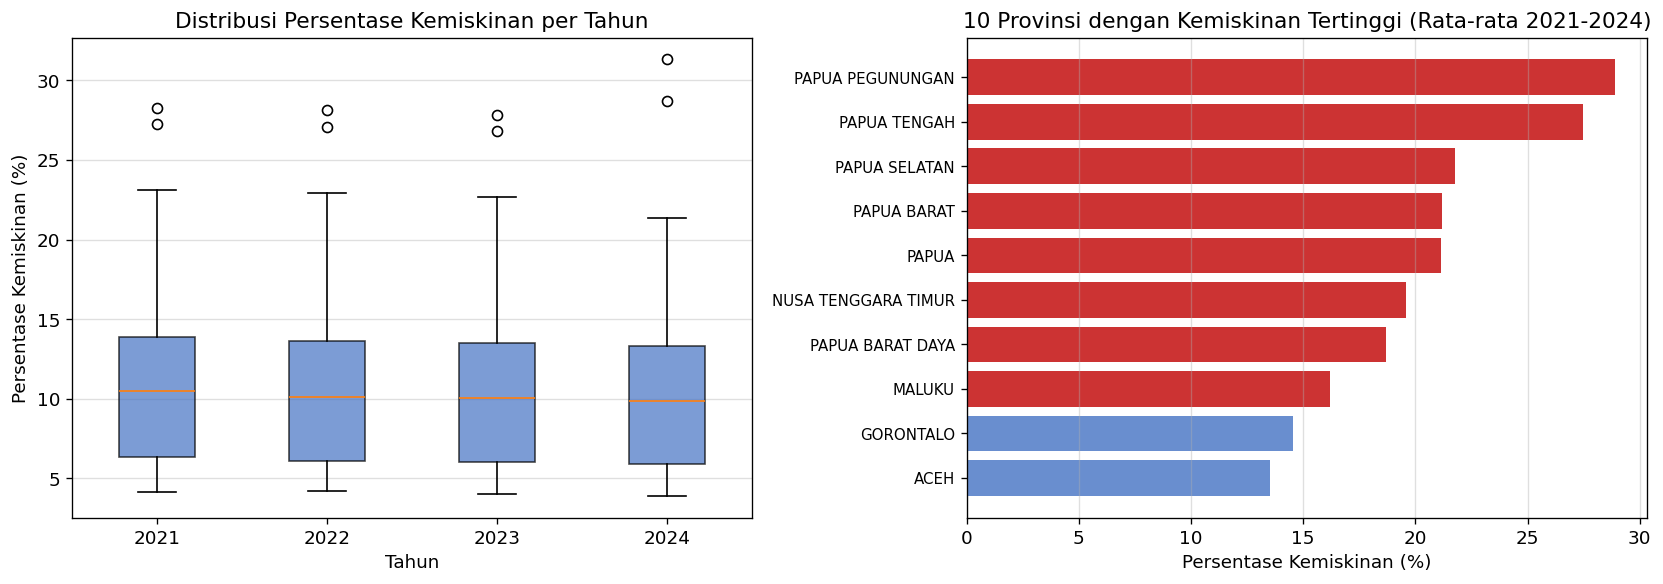


Top 10 Provinsi Kemiskinan Tertinggi (Rata-rata 2021-2024)
provinsi
PAPUA PEGUNUNGAN       28.88
PAPUA TENGAH           27.45
PAPUA SELATAN          21.79
PAPUA BARAT            21.21
PAPUA                  21.13
NUSA TENGGARA TIMUR    19.57
PAPUA BARAT DAYA       18.70
MALUKU                 16.18
GORONTALO              14.53
ACEH                   13.54


In [10]:
# Distribusi kemiskinan per tahun
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot kemiskinan per tahun
years = sorted(df['tahun'].unique())
data_by_year = [df[df['tahun'] == y]['kemiskinan_pct'].values for y in years]
axes[0].boxplot(data_by_year, labels=years, patch_artist=True,
                boxprops=dict(facecolor='#4472C4', alpha=0.7))
axes[0].set_title('Distribusi Persentase Kemiskinan per Tahun')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Persentase Kemiskinan (%)')
axes[0].grid(axis='y', alpha=0.4)

# Rata-rata kemiskinan per provinsi (rata-rata semua tahun)
prov_avg = df.groupby('provinsi')['kemiskinan_pct'].mean().sort_values(ascending=False)
top10 = prov_avg.head(10)
colors_bar = ['#C00000' if v >= prov_avg.median() * 1.5 else '#4472C4' for v in top10.values]
axes[1].barh(range(len(top10)), top10.values, color=colors_bar, alpha=0.8)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10.index, fontsize=9)
axes[1].set_title('10 Provinsi dengan Kemiskinan Tertinggi (Rata-rata 2021-2024)')
axes[1].set_xlabel('Persentase Kemiskinan (%)')
axes[1].grid(axis='x', alpha=0.4)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plot_distribusi_kemiskinan.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Provinsi Kemiskinan Tertinggi (Rata-rata 2021-2024)')
print(top10.round(2).to_string())

## 4. Membangun Matriks Bobot Spasial (Spatial Weight Matrix)

Karena tidak ada shapefile, kita gunakan **pendekatan ketetanggaan berbasis posisi geografis** menggunakan koordinat sentroid provinsi Indonesia yang telah dikodekan secara manual. Matriks bobot yang digunakan adalah **K-Nearest Neighbors (KNN dengan k=5)** dan juga **Queen Contiguity** akan disimulasikan.

Alternatif: jika shapefile tersedia, gunakan `gpd.read_file()` dan `Queen.from_dataframe()`.

In [11]:
# Koordinat sentroid 38 provinsi Indonesia (longitude, latitude)
# Sumber: estimasi geografis berdasarkan peta administrasi
PROVINSI_COORDS = {
    'ACEH': (95.317, 4.695),
    'SUMATERA UTARA': (98.672, 2.115),
    'SUMATERA BARAT': (100.355, -0.744),
    'RIAU': (101.447, 0.293),
    'JAMBI': (102.437, -1.609),
    'SUMATERA SELATAN': (104.761, -3.319),
    'BENGKULU': (102.346, -3.800),
    'LAMPUNG': (105.322, -4.558),
    'KEPULAUAN BANGKA BELITUNG': (106.116, -2.741),
    'KEPULAUAN RIAU': (104.030, 0.921),
    'DKI JAKARTA': (106.845, -6.208),
    'JAWA BARAT': (107.619, -6.902),
    'JAWA TENGAH': (110.165, -7.150),
    'DI YOGYAKARTA': (110.365, -7.800),
    'JAWA TIMUR': (112.752, -7.536),
    'BANTEN': (106.064, -6.406),
    'BALI': (115.188, -8.409),
    'NUSA TENGGARA BARAT': (116.419, -8.600),
    'NUSA TENGGARA TIMUR': (121.079, -8.657),
    'KALIMANTAN BARAT': (109.697, -0.023),
    'KALIMANTAN TENGAH': (113.941, -1.681),
    'KALIMANTAN SELATAN': (115.283, -3.093),
    'KALIMANTAN TIMUR': (116.419, 1.681),
    'KALIMANTAN UTARA': (116.593, 3.073),
    'SULAWESI UTARA': (124.841, 0.632),
    'SULAWESI TENGAH': (121.445, -1.431),
    'SULAWESI SELATAN': (120.190, -3.668),
    'SULAWESI TENGGARA': (122.390, -4.145),
    'GORONTALO': (122.446, 0.541),
    'SULAWESI BARAT': (119.313, -2.840),
    'MALUKU': (128.175, -3.238),
    'MALUKU UTARA': (127.624, 1.571),
    'PAPUA BARAT': (133.173, -1.336),
    'PAPUA': (138.379, -4.269),
    'PAPUA PEGUNUNGAN': (138.600, -4.000),
    'PAPUA SELATAN': (138.500, -6.500),
    'PAPUA TENGAH': (136.500, -3.500),
    'PAPUA BARAT DAYA': (131.500, -1.500)
}

# Buat dataframe koordinat
coords_df = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in PROVINSI_COORDS.items()],
    columns=['provinsi', 'lon', 'lat']
)

print(f'Total provinsi dengan koordinat: {len(coords_df)}')

# Cek provinsi di dataset yang tidak ada di koordinat
prov_in_data = set(df['provinsi'].unique())
prov_in_coords = set(coords_df['provinsi'].unique())
missing_coords = prov_in_data - prov_in_coords
print(f'\nProvinsi di data tapi tidak ada koordinat: {missing_coords}')

missing_data = prov_in_coords - prov_in_data
print(f'Provinsi di koordinat tapi tidak di data: {missing_data}')

Total provinsi dengan koordinat: 38

Provinsi di data tapi tidak ada koordinat: {'KEP. BANGKA BELITUNG', 'KEP. RIAU'}
Provinsi di koordinat tapi tidak di data: {'KEPULAUAN BANGKA BELITUNG', 'KEPULAUAN RIAU'}


In [12]:
# Mapping nama provinsi jika ada perbedaan nama
PROV_MAP = {
    'KEP. BANGKA BELITUNG': 'KEPULAUAN BANGKA BELITUNG',
    'KEP. RIAU': 'KEPULAUAN RIAU',
    'DKI JAKARTA': 'DKI JAKARTA',
    'DI YOGYAKARTA': 'DI YOGYAKARTA',
    'NUSA TENGGARA BARAT': 'NUSA TENGGARA BARAT',
    'NUSA TENGGARA TIMUR': 'NUSA TENGGARA TIMUR',
}

# Standardisasi nama provinsi di dataset
df['provinsi'] = df['provinsi'].replace(PROV_MAP)

# Standardisasi nama di df agar cocok dengan PROVINSI_COORDS
# Cek actual names di dataset
print('Nama provinsi dalam dataset:')
for p in sorted(df['provinsi'].unique()):
    matched = p in PROVINSI_COORDS
    print(f'  {p:45s} -> {"OK" if matched else "TIDAK COCOK"}')

Nama provinsi dalam dataset:
  ACEH                                          -> OK
  BALI                                          -> OK
  BANTEN                                        -> OK
  BENGKULU                                      -> OK
  DI YOGYAKARTA                                 -> OK
  DKI JAKARTA                                   -> OK
  GORONTALO                                     -> OK
  JAMBI                                         -> OK
  JAWA BARAT                                    -> OK
  JAWA TENGAH                                   -> OK
  JAWA TIMUR                                    -> OK
  KALIMANTAN BARAT                              -> OK
  KALIMANTAN SELATAN                            -> OK
  KALIMANTAN TENGAH                             -> OK
  KALIMANTAN TIMUR                              -> OK
  KALIMANTAN UTARA                              -> OK
  KEPULAUAN BANGKA BELITUNG                     -> OK
  KEPULAUAN RIAU                                -> OK

In [13]:
# Fungsi untuk mencari koordinat dengan fuzzy match sederhana
def get_coords(prov_name, coords_dict):
    if prov_name in coords_dict:
        return coords_dict[prov_name]
    # Coba partial match
    for key in coords_dict:
        if prov_name in key or key in prov_name:
            return coords_dict[key]
    return None

# Tambahkan koordinat ke df
df['lon'] = df['provinsi'].apply(lambda x: get_coords(x, {k: v[0] for k, v in PROVINSI_COORDS.items()}))
df['lat'] = df['provinsi'].apply(lambda x: get_coords(x, {k: v[1] for k, v in PROVINSI_COORDS.items()}))

# Cek berapa yang tidak dapat koordinat
no_coords = df[df['lon'].isnull()]['provinsi'].unique()
print(f'Provinsi tanpa koordinat: {no_coords}')

# Drop baris tanpa koordinat
df = df.dropna(subset=['lon', 'lat'])
print(f'\nShape setelah filter koordinat: {df.shape}')

Provinsi tanpa koordinat: []

Shape setelah filter koordinat: (151, 23)


In [14]:
# Ambil data satu tahun untuk analisis spasial (2023 sebagai contoh utama)
# Analisis akan dilakukan per tahun kemudian
df_2023 = df[df['tahun'] == 2023].copy().reset_index(drop=True)

print(f'Data 2023: {df_2023.shape[0]} provinsi')
print(df_2023[['provinsi', 'kemiskinan_pct', 'lon', 'lat']].to_string())

Data 2023: 38 provinsi
                     provinsi  kemiskinan_pct      lon    lat
0                        ACEH          13.545   95.317  4.695
1              SUMATERA UTARA           7.670   98.672  2.115
2              SUMATERA BARAT           5.685  100.355 -0.744
3                        RIAU           6.520  101.447  0.293
4                       JAMBI           7.420  102.437 -1.609
5            SUMATERA SELATAN          11.145  104.761 -3.319
6                    BENGKULU          13.280  102.346 -3.800
7                     LAMPUNG          10.865  105.322 -4.558
8   KEPULAUAN BANGKA BELITUNG           4.800  106.116 -2.741
9              KEPULAUAN RIAU           5.235  104.030  0.921
10                DKI JAKARTA           4.290  106.845 -6.208
11                 JAWA BARAT           7.350  107.619 -6.902
12                JAWA TENGAH          10.175  110.165 -7.150
13              DI YOGYAKARTA          10.720  110.365 -7.800
14                 JAWA TIMUR           9.955  

In [15]:
# Bangun matriks bobot spasial KNN (k=5)
coords_arr = list(zip(df_2023['lon'].values, df_2023['lat'].values))

# KNN weight matrix dengan k=5
W_knn = KNN.from_array(coords_arr, k=5)
W_knn.transform = 'r'  # Row-standardize

print('=== Matriks Bobot Spasial KNN (k=5) ===')
print(f'Jumlah observasi: {W_knn.n}')
print(f'Rata-rata tetangga: {W_knn.mean_neighbors:.2f}')
print(f'Min tetangga: {W_knn.min_neighbors}')
print(f'Max tetangga: {W_knn.max_neighbors}')
print(f'Sparsity: {W_knn.pct_nonzero:.2f}%')

=== Matriks Bobot Spasial KNN (k=5) ===
Jumlah observasi: 38
Rata-rata tetangga: 5.00
Min tetangga: 5
Max tetangga: 5
Sparsity: 13.16%


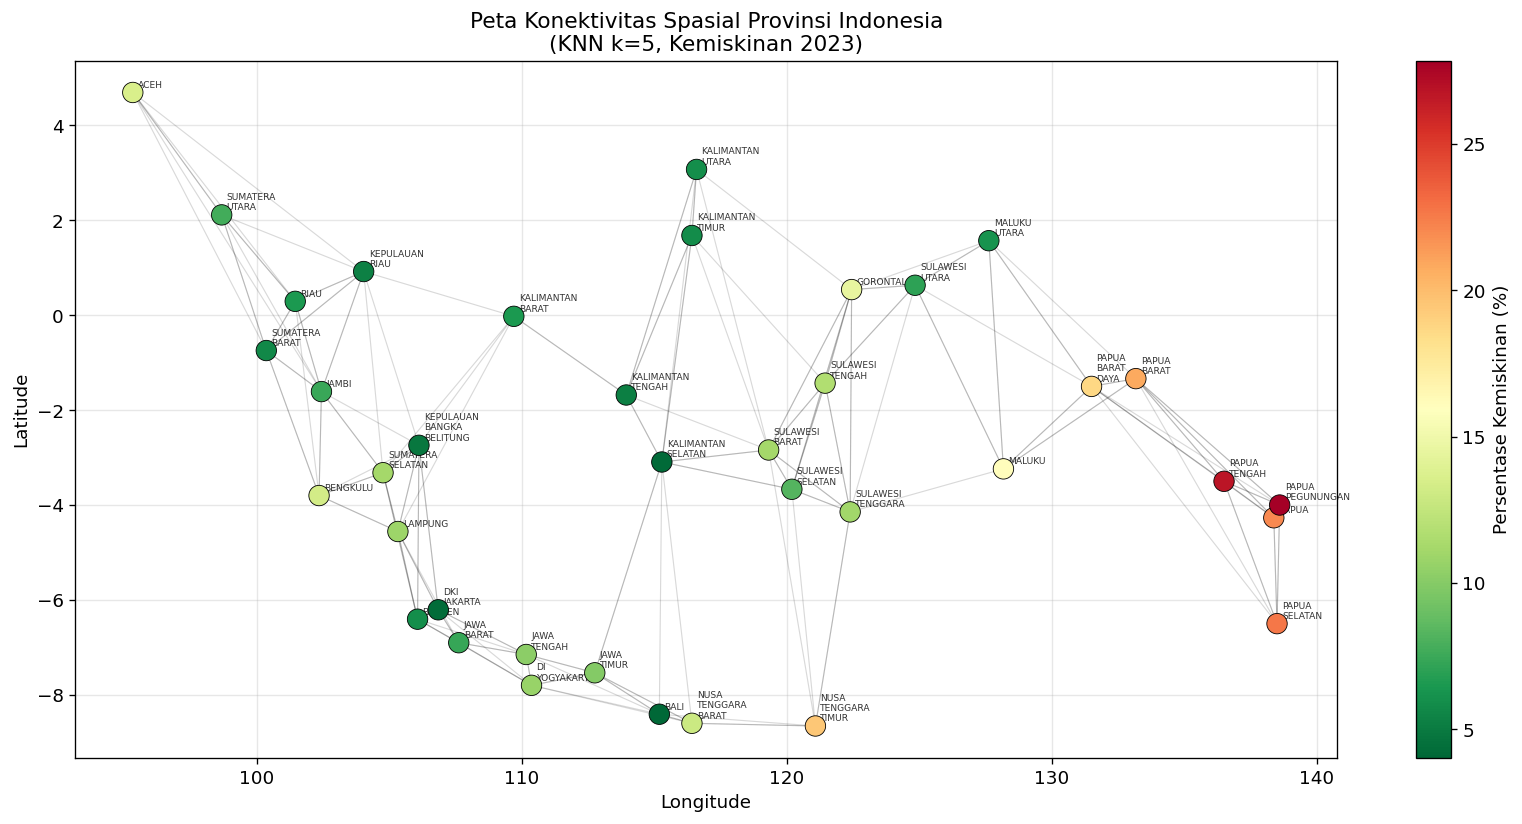

In [16]:
# Visualisasi konektivitas spasial
fig, ax = plt.subplots(figsize=(14, 7))

# Plot titik provinsi
lons = df_2023['lon'].values
lats = df_2023['lat'].values
pov_vals = df_2023['kemiskinan_pct'].values

# Gambar koneksi antar tetangga
for i, neighbors in W_knn.neighbors.items():
    for j in neighbors:
        ax.plot([lons[i], lons[j]], [lats[i], lats[j]],
                'k-', alpha=0.15, linewidth=0.7)

# Plot titik dengan warna kemiskinan
sc = ax.scatter(lons, lats, c=pov_vals, cmap='RdYlGn_r',
                s=150, zorder=5, edgecolors='black', linewidths=0.5)

# Label provinsi
for i, row in df_2023.iterrows():
    ax.annotate(row['provinsi'].replace(' ', '\n'),
                xy=(row['lon'], row['lat']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=5.5, alpha=0.8)

plt.colorbar(sc, ax=ax, label='Persentase Kemiskinan (%)')
ax.set_title('Peta Konektivitas Spasial Provinsi Indonesia\n(KNN k=5, Kemiskinan 2023)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_konektivitas_spasial.png', bbox_inches='tight')
plt.show()

## 5. Global Moran's I

Global Moran's I mengukur autokorelasi spasial secara keseluruhan.
- **I > 0**: klaster spasial positif (wilayah dengan nilai serupa berdekatan)
- **I < 0**: dispersi spasial (wilayah berbeda nilai berdekatan)
- **I ≈ 0**: pola acak

In [17]:
# Hitung Global Moran's I per tahun
results_global = []

for tahun in sorted(df['tahun'].unique()):
    df_t = df[df['tahun'] == tahun].copy().reset_index(drop=True)
    coords_t = list(zip(df_t['lon'].values, df_t['lat'].values))
    W_t = KNN.from_array(coords_t, k=5)
    W_t.transform = 'r'

    y = df_t['kemiskinan_pct'].values

    # Global Moran's I
    moran = Moran(y, W_t, permutations=999)

    results_global.append({
        'tahun': tahun,
        'n_provinsi': len(df_t),
        'moran_i': moran.I,
        'expected_i': moran.EI,
        'z_score': moran.z_norm,
        'p_value': moran.p_norm,
        'p_sim': moran.p_sim,
        'signifikan': moran.p_sim < 0.05
    })

    print(f'\nTahun {tahun}:')
    print(f'  Moran\'s I      = {moran.I:.4f}')
    print(f'  Expected I    = {moran.EI:.4f}')
    print(f'  Z-score       = {moran.z_norm:.4f}')
    print(f'  p-value (norm)= {moran.p_norm:.4f}')
    print(f'  p-value (sim) = {moran.p_sim:.4f}')
    print(f'  Signifikan?   = {moran.p_sim < 0.05}')
    if moran.I > 0 and moran.p_sim < 0.05:
        print(f'  Interpretasi  : Terdapat KLASTER SPASIAL POSITIF yang signifikan')
    elif moran.I < 0 and moran.p_sim < 0.05:
        print(f'  Interpretasi  : Terdapat DISPERSI SPASIAL yang signifikan')
    else:
        print(f'  Interpretasi  : Pola ACAK (tidak signifikan)')

df_global = pd.DataFrame(results_global)
print('\n=== Ringkasan Global Moran\'s I ===')
print(df_global.to_string(index=False))


Tahun 2021:
  Moran's I      = 0.6409
  Expected I    = -0.0278
  Z-score       = 7.4433
  p-value (norm)= 0.0000
  p-value (sim) = 0.0010
  Signifikan?   = True
  Interpretasi  : Terdapat KLASTER SPASIAL POSITIF yang signifikan

Tahun 2022:
  Moran's I      = 0.6409
  Expected I    = -0.0270
  Z-score       = 7.5449
  p-value (norm)= 0.0000
  p-value (sim) = 0.0010
  Signifikan?   = True
  Interpretasi  : Terdapat KLASTER SPASIAL POSITIF yang signifikan

Tahun 2023:
  Moran's I      = 0.6384
  Expected I    = -0.0270
  Z-score       = 7.5175
  p-value (norm)= 0.0000
  p-value (sim) = 0.0010
  Signifikan?   = True
  Interpretasi  : Terdapat KLASTER SPASIAL POSITIF yang signifikan

Tahun 2024:
  Moran's I      = 0.5782
  Expected I    = -0.0270
  Z-score       = 6.8371
  p-value (norm)= 0.0000
  p-value (sim) = 0.0010
  Signifikan?   = True
  Interpretasi  : Terdapat KLASTER SPASIAL POSITIF yang signifikan

=== Ringkasan Global Moran's I ===
 tahun  n_provinsi  moran_i  expected_i  z_s

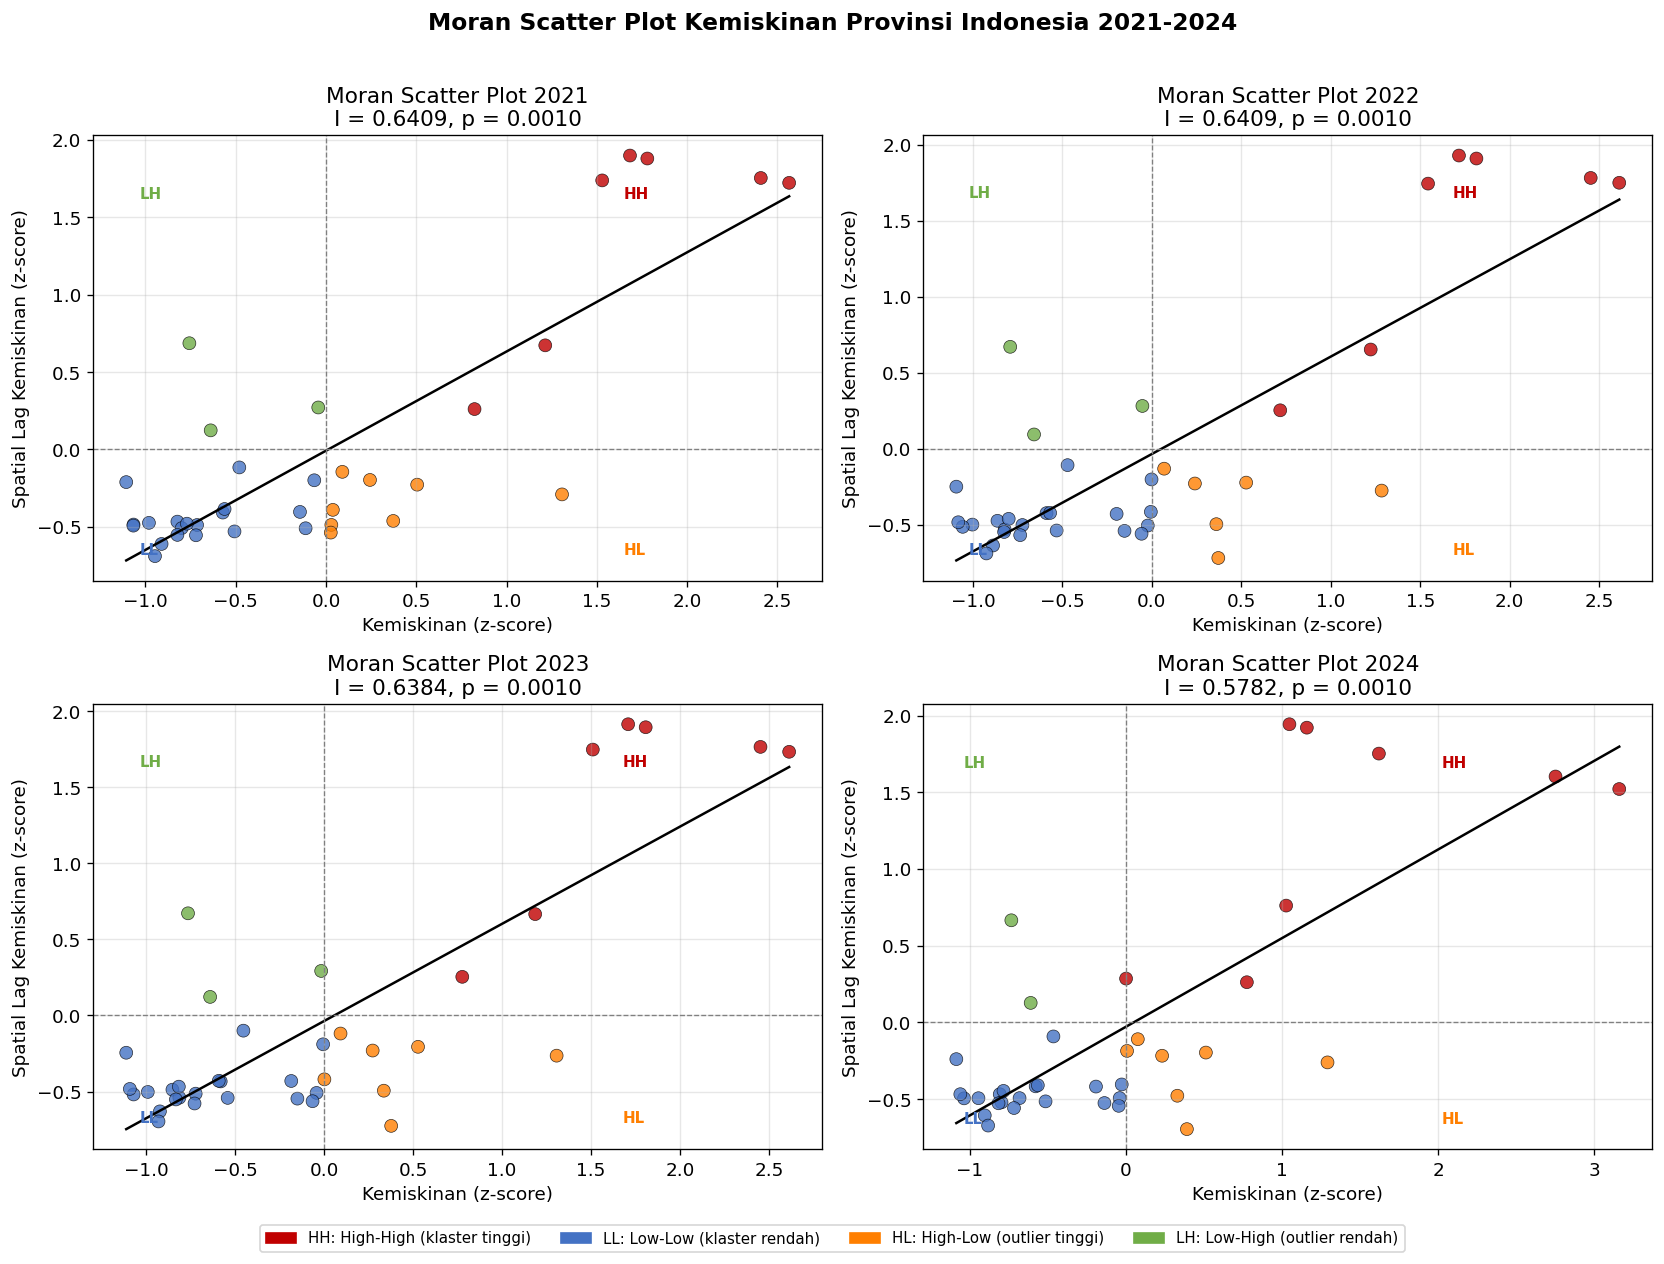

In [18]:
# Moran Scatter Plot untuk setiap tahun
years = sorted(df['tahun'].unique())
n_years = len(years)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, tahun in enumerate(years):
    ax = axes[idx]
    df_t = df[df['tahun'] == tahun].copy().reset_index(drop=True)
    coords_t = list(zip(df_t['lon'].values, df_t['lat'].values))
    W_t = KNN.from_array(coords_t, k=5)
    W_t.transform = 'r'

    y = df_t['kemiskinan_pct'].values
    moran = Moran(y, W_t, permutations=999)

    # Standarisasi y dan spatial lag
    y_std = (y - y.mean()) / y.std()
    lag_y_std = libpysal.weights.lag_spatial(W_t, y_std)

    # Warna berdasarkan kuadran Moran
    colors = []
    for yi, lyi in zip(y_std, lag_y_std):
        if yi >= 0 and lyi >= 0:
            colors.append('#C00000')    # HH: merah (High-High)
        elif yi < 0 and lyi < 0:
            colors.append('#4472C4')    # LL: biru (Low-Low)
        elif yi >= 0 and lyi < 0:
            colors.append('#FF7F00')    # HL: oranye (High-Low)
        else:
            colors.append('#70AD47')    # LH: hijau (Low-High)

    ax.scatter(y_std, lag_y_std, c=colors, alpha=0.8, s=60, edgecolors='black', linewidths=0.4)

    slope, intercept, r, p, se = stats.linregress(y_std, lag_y_std)
    x_line = np.linspace(y_std.min(), y_std.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, 'k-', linewidth=1.5)

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

    ax.set_xlabel('Kemiskinan (z-score)')
    ax.set_ylabel('Spatial Lag Kemiskinan (z-score)')
    ax.set_title(f'Moran Scatter Plot {tahun}\nI = {moran.I:.4f}, p = {moran.p_sim:.4f}')

    xr = ax.get_xlim()
    yr = ax.get_ylim()
    ax.text(xr[1]*0.6, yr[1]*0.8, 'HH', color='#C00000', fontsize=9, fontweight='bold')
    ax.text(xr[0]*0.8, yr[0]*0.8, 'LL', color='#4472C4', fontsize=9, fontweight='bold')
    ax.text(xr[1]*0.6, yr[0]*0.8, 'HL', color='#FF7F00', fontsize=9, fontweight='bold')
    ax.text(xr[0]*0.8, yr[1]*0.8, 'LH', color='#70AD47', fontsize=9, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Moran Scatter Plot Kemiskinan Provinsi Indonesia 2021-2024',
             fontsize=14, fontweight='bold', y=1.01)
legend_patches = [
    mpatches.Patch(color='#C00000', label='HH: High-High (klaster tinggi)'),
    mpatches.Patch(color='#4472C4', label='LL: Low-Low (klaster rendah)'),
    mpatches.Patch(color='#FF7F00', label='HL: High-Low (outlier tinggi)'),
    mpatches.Patch(color='#70AD47', label='LH: Low-High (outlier rendah)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('plot_moran_scatter.png', bbox_inches='tight')
plt.show()

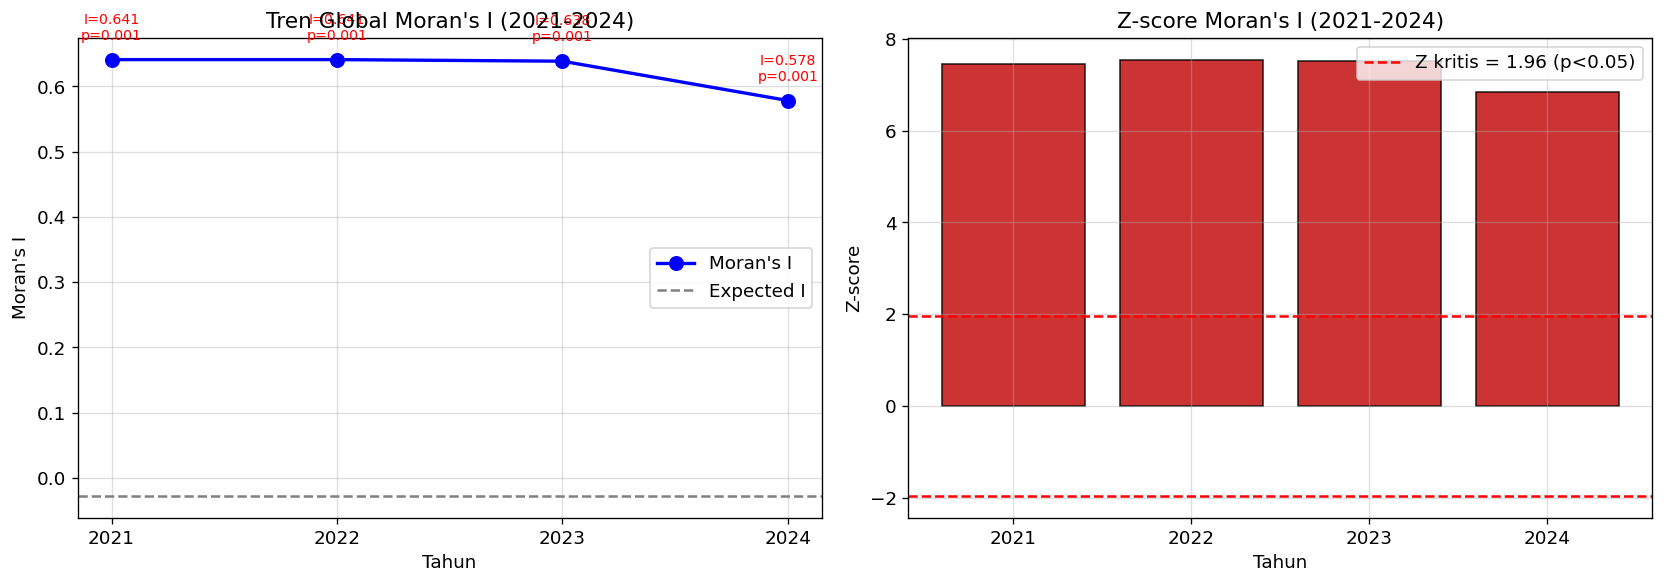

In [19]:
# Tren Global Moran's I lintas tahun
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_global['tahun'], df_global['moran_i'], 'bo-', linewidth=2, markersize=8, label="Moran's I")
ax.axhline(df_global['expected_i'].mean(), color='gray', linestyle='--', label='Expected I')
for _, row in df_global.iterrows():
    color = 'red' if row['signifikan'] else 'black'
    ax.annotate(f"I={row['moran_i']:.3f}\np={row['p_sim']:.3f}",
                xy=(row['tahun'], row['moran_i']),
                xytext=(0, 12), textcoords='offset points',
                fontsize=8.5, ha='center', color=color)
ax.set_xlabel('Tahun')
ax.set_ylabel("Moran's I")
ax.set_title("Tren Global Moran's I (2021-2024)")
ax.legend()
ax.grid(alpha=0.4)
ax.set_xticks(df_global['tahun'])

ax2 = axes[1]
ax2.bar(df_global['tahun'], df_global['z_score'],
        color=['#C00000' if s else '#4472C4' for s in df_global['signifikan']],
        alpha=0.8, edgecolor='black')
ax2.axhline(1.96, color='red', linestyle='--', label='Z kritis = 1.96 (p<0.05)')
ax2.axhline(-1.96, color='red', linestyle='--')
ax2.set_xlabel('Tahun')
ax2.set_ylabel('Z-score')
ax2.set_title("Z-score Moran's I (2021-2024)")
ax2.legend()
ax2.grid(alpha=0.4)
ax2.set_xticks(df_global['tahun'])

plt.tight_layout()
plt.savefig('plot_moran_trend.png', bbox_inches='tight')
plt.show()

## 6. LISA (Local Indicators of Spatial Association)

LISA mengidentifikasi klaster dan outlier spasial **lokal** di setiap unit (provinsi). Tipe klaster LISA:
- **HH (High-High)**: hotspot — provinsi miskin dikelilingi provinsi miskin
- **LL (Low-Low)**: coldspot — provinsi kaya dikelilingi provinsi kaya
- **HL (High-Low)**: outlier — provinsi miskin dikelilingi provinsi kaya
- **LH (Low-High)**: outlier — provinsi kaya dikelilingi provinsi miskin

In [20]:
# Hitung LISA per tahun
lisa_results_all = []

LISA_COLORS = {
    'HH': '#C00000',
    'LL': '#4472C4',
    'HL': '#FF7F00',
    'LH': '#70AD47',
    'NS': '#D3D3D3'
}

for tahun in sorted(df['tahun'].unique()):
    df_t = df[df['tahun'] == tahun].copy().reset_index(drop=True)
    coords_t = list(zip(df_t['lon'].values, df_t['lat'].values))
    W_t = KNN.from_array(coords_t, k=5)
    W_t.transform = 'r'

    y = df_t['kemiskinan_pct'].values

    # Local Moran's I (LISA)
    lisa = Moran_Local(y, W_t, permutations=999)

    y_std = (y - y.mean()) / y.std()
    lag_y_std = libpysal.weights.lag_spatial(W_t, y_std)

    # Tentukan kuadran
    sig_mask = lisa.p_sim < 0.05
    kuadran = []
    for i in range(len(y_std)):
        if not sig_mask[i]:
            kuadran.append('NS')
        elif y_std[i] >= 0 and lag_y_std[i] >= 0:
            kuadran.append('HH')
        elif y_std[i] < 0 and lag_y_std[i] < 0:
            kuadran.append('LL')
        elif y_std[i] >= 0 and lag_y_std[i] < 0:
            kuadran.append('HL')
        else:
            kuadran.append('LH')

    for i, row in df_t.iterrows():
        lisa_results_all.append({
            'tahun': tahun,
            'provinsi': row['provinsi'],
            'kemiskinan_pct': row['kemiskinan_pct'],
            'local_moran_i': lisa.Is[i],
            'p_value': lisa.p_sim[i],
            'kuadran': kuadran[i],
            'signifikan': sig_mask[i],
            'lon': row['lon'],
            'lat': row['lat']
        })

df_lisa = pd.DataFrame(lisa_results_all)

print('Hasil LISA per Tahun')
for tahun in sorted(df_lisa['tahun'].unique()):
    sub = df_lisa[df_lisa['tahun'] == tahun]
    print(f'\nTahun {tahun}:')
    count_sig = sub[sub['signifikan']].groupby('kuadran').size()
    count_all = sub.groupby('kuadran').size()
    print(f'  Klaster signifikan (p<0.05): {sub["signifikan"].sum()} dari {len(sub)} provinsi')
    print('  Distribusi kuadran (signifikan):')
    for k in ['HH', 'LL', 'HL', 'LH', 'NS']:
        n = count_all.get(k, 0)
        if n > 0:
            print(f'    {k}: {n} provinsi')
    sig_df = sub[sub['signifikan']].sort_values('kuadran')
    if len(sig_df) > 0:
        print('  Provinsi signifikan:')
        for _, r in sig_df.iterrows():
            print(f'    [{r["kuadran"]}] {r["provinsi"]} (I={r["local_moran_i"]:.4f}, p={r["p_value"]:.4f})')

Hasil LISA per Tahun

Tahun 2021:
  Klaster signifikan (p<0.05): 6 dari 37 provinsi
  Distribusi kuadran (signifikan):
    HH: 5 provinsi
    LL: 1 provinsi
    NS: 31 provinsi
  Provinsi signifikan:
    [HH] PAPUA BARAT (I=2.5875, p=0.0010)
    [HH] PAPUA (I=3.1109, p=0.0010)
    [HH] PAPUA SELATAN (I=3.2550, p=0.0010)
    [HH] PAPUA TENGAH (I=4.1103, p=0.0010)
    [HH] PAPUA PEGUNUNGAN (I=4.2999, p=0.0010)
    [LL] KALIMANTAN TENGAH (I=0.6354, p=0.0260)

Tahun 2022:
  Klaster signifikan (p<0.05): 8 dari 38 provinsi
  Distribusi kuadran (signifikan):
    HH: 5 provinsi
    LL: 2 provinsi
    HL: 1 provinsi
    NS: 30 provinsi
  Provinsi signifikan:
    [HH] PAPUA BARAT (I=2.6228, p=0.0020)
    [HH] PAPUA (I=3.2252, p=0.0010)
    [HH] PAPUA SELATAN (I=3.3741, p=0.0010)
    [HH] PAPUA TENGAH (I=4.2573, p=0.0010)
    [HH] PAPUA PEGUNUNGAN (I=4.4530, p=0.0010)
    [HL] ACEH (I=-0.2601, p=0.0280)
    [LL] KEPULAUAN RIAU (I=0.5512, p=0.0450)
    [LL] KALIMANTAN TENGAH (I=0.6215, p=0.0270)



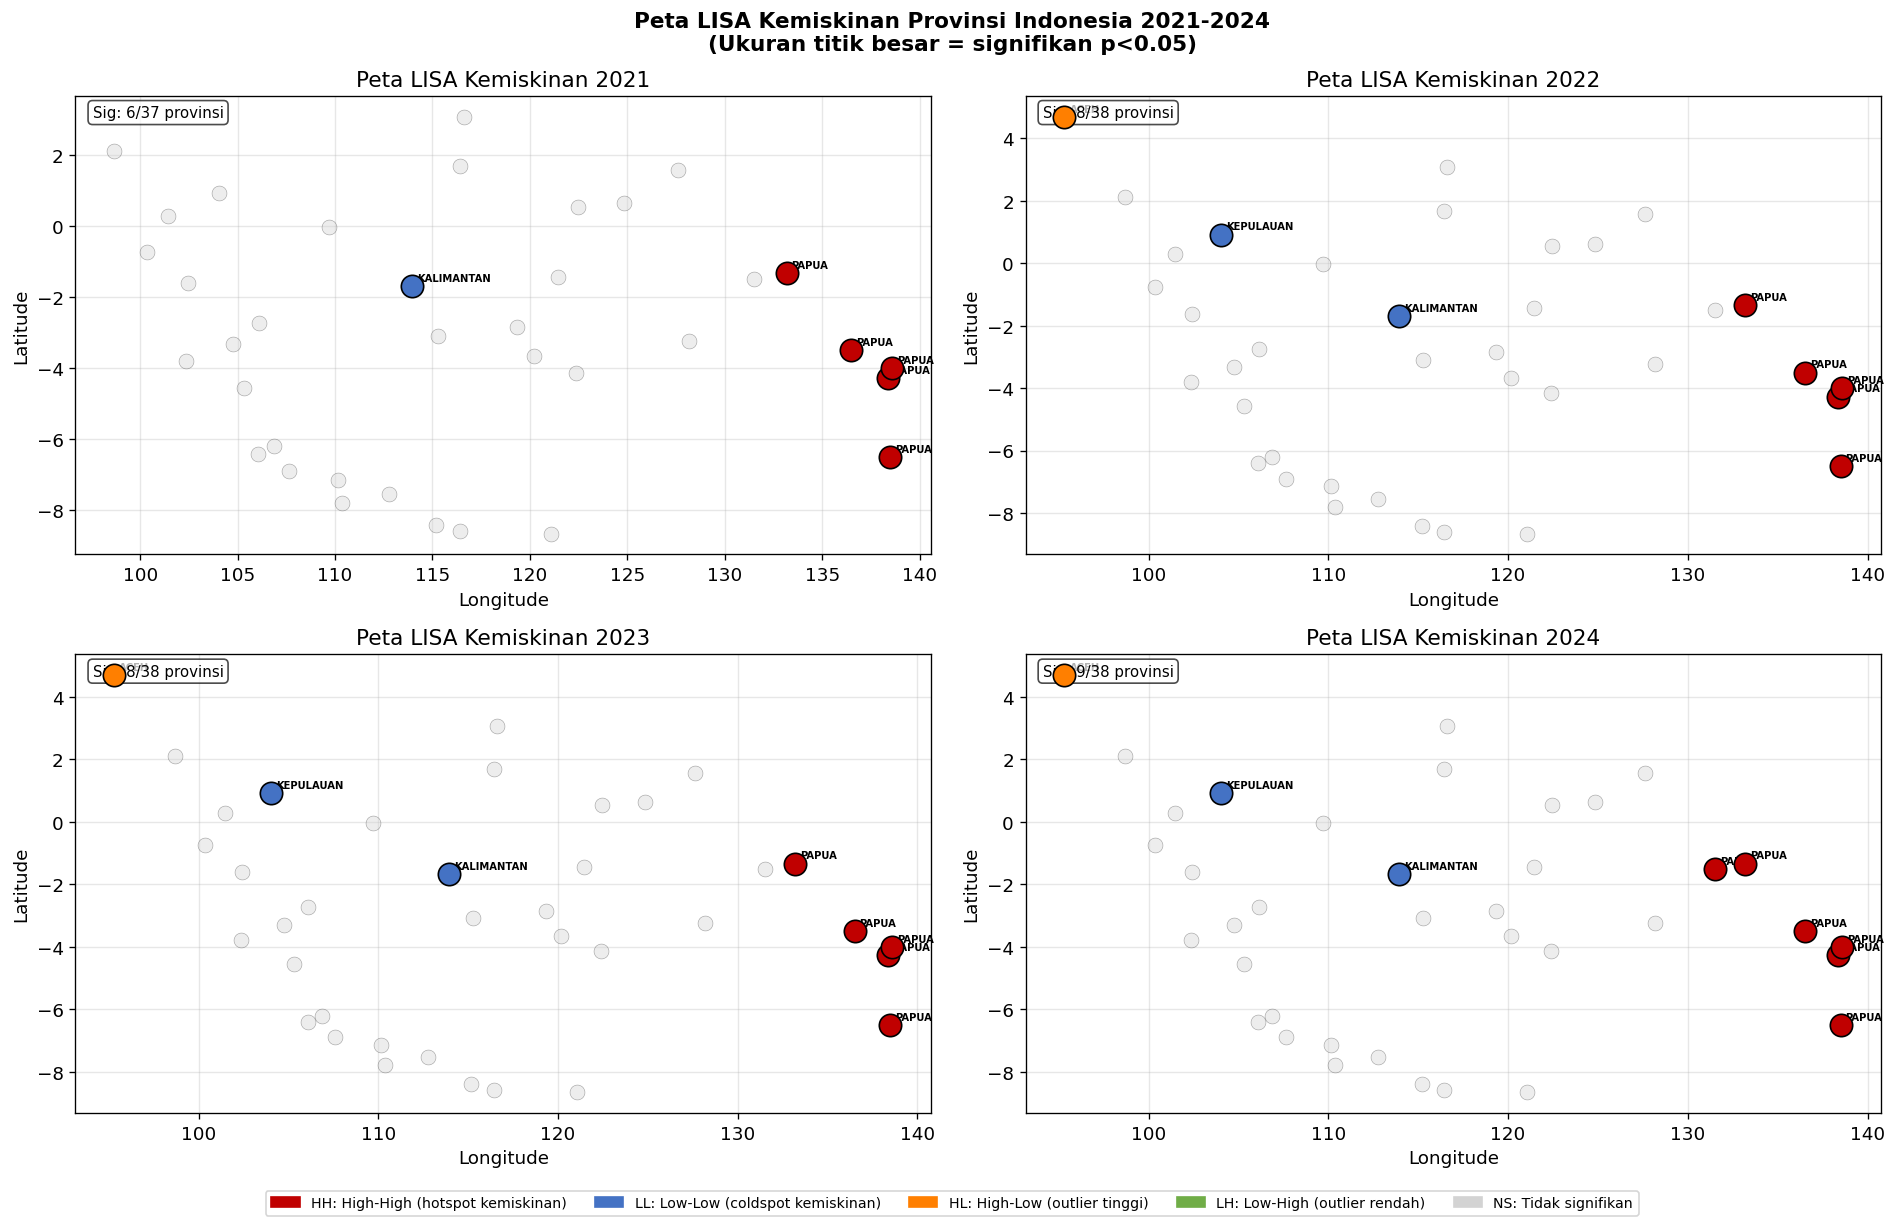

In [21]:
# Peta LISA per tahun
years = sorted(df_lisa['tahun'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

LISA_COLORS = {
    'HH': '#C00000',
    'LL': '#4472C4',
    'HL': '#FF7F00',
    'LH': '#70AD47',
    'NS': '#D3D3D3'
}

for idx, tahun in enumerate(years):
    ax = axes[idx]
    sub = df_lisa[df_lisa['tahun'] == tahun]

    for _, row in sub.iterrows():
        ax.scatter(row['lon'], row['lat'],
                   c=LISA_COLORS[row['kuadran']],
                   s=180 if row['signifikan'] else 80,
                   edgecolors='black',
                   linewidths=1.0 if row['signifikan'] else 0.3,
                   zorder=5,
                   alpha=1.0 if row['signifikan'] else 0.4)
        if row['signifikan']:
            ax.annotate(row['provinsi'].split()[0],
                        xy=(row['lon'], row['lat']),
                        xytext=(3, 3), textcoords='offset points',
                        fontsize=6, fontweight='bold')

    ax.set_title(f'Peta LISA Kemiskinan {tahun}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(alpha=0.3)

    sig_count = sub['signifikan'].sum()
    ax.text(0.02, 0.98, f'Sig: {sig_count}/{len(sub)} provinsi',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

legend_patches = [
    mpatches.Patch(color=LISA_COLORS['HH'], label='HH: High-High (hotspot kemiskinan)'),
    mpatches.Patch(color=LISA_COLORS['LL'], label='LL: Low-Low (coldspot kemiskinan)'),
    mpatches.Patch(color=LISA_COLORS['HL'], label='HL: High-Low (outlier tinggi)'),
    mpatches.Patch(color=LISA_COLORS['LH'], label='LH: Low-High (outlier rendah)'),
    mpatches.Patch(color=LISA_COLORS['NS'], label='NS: Tidak signifikan'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Peta LISA Kemiskinan Provinsi Indonesia 2021-2024\n(Ukuran titik besar = signifikan p<0.05)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_lisa_map.png', bbox_inches='tight')
plt.show()

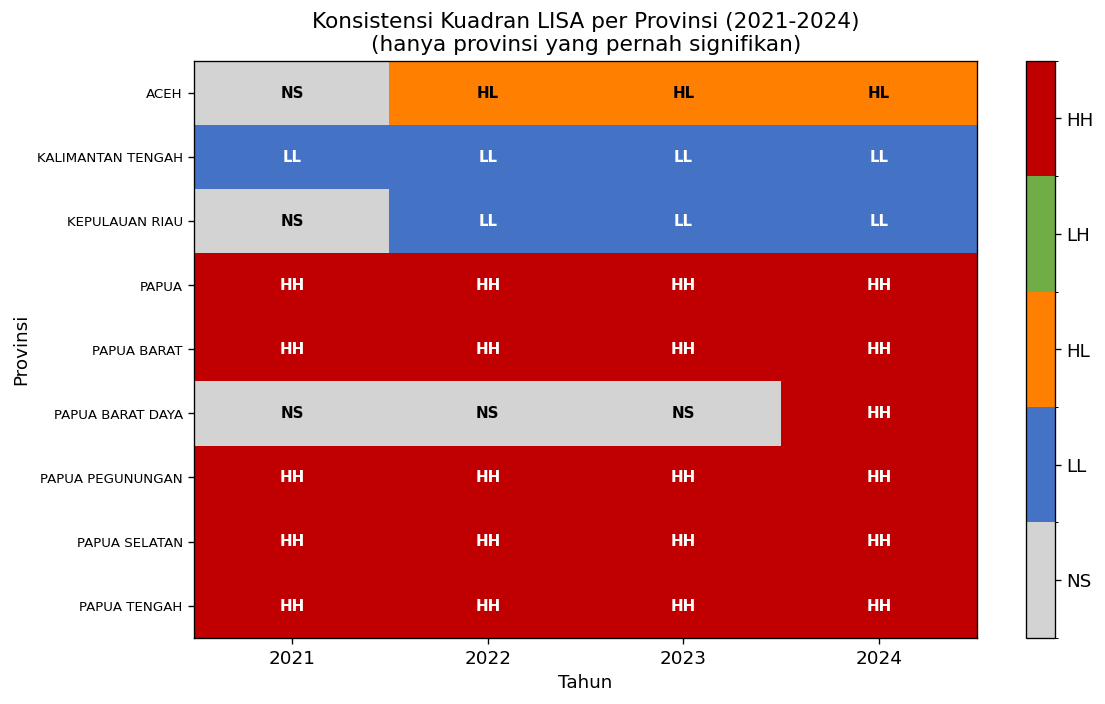

In [22]:
pivot_kuadran = df_lisa.pivot(index='provinsi', columns='tahun', values='kuadran')

KUADRAN_CODE = {'HH': 4, 'LH': 3, 'HL': 2, 'LL': 1, 'NS': 0}
pivot_num = pivot_kuadran.applymap(lambda x: KUADRAN_CODE.get(x, 0))

ever_sig = df_lisa[df_lisa['signifikan']]['provinsi'].unique()
pivot_num_sig = pivot_num.loc[pivot_num.index.isin(ever_sig)]

if len(pivot_num_sig) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_num_sig) * 0.4)))

    cmap = mcolors.ListedColormap(['#D3D3D3', '#4472C4', '#FF7F00', '#70AD47', '#C00000'])
    bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    im = ax.imshow(pivot_num_sig.values, cmap=cmap, norm=norm, aspect='auto')

    ax.set_xticks(range(len(pivot_num_sig.columns)))
    ax.set_xticklabels(pivot_num_sig.columns)
    ax.set_yticks(range(len(pivot_num_sig.index)))
    ax.set_yticklabels(pivot_num_sig.index, fontsize=8)

    for i in range(len(pivot_num_sig.index)):
        for j in range(len(pivot_num_sig.columns)):
            val = pivot_num_sig.values[i, j]
            label = {v: k for k, v in KUADRAN_CODE.items()}[val]
            ax.text(j, i, label, ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if val in [1, 4] else 'black')

    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4])
    cbar.ax.set_yticklabels(['NS', 'LL', 'HL', 'LH', 'HH'])

    ax.set_title('Konsistensi Kuadran LISA per Provinsi (2021-2024)\n(hanya provinsi yang pernah signifikan)')
    ax.set_xlabel('Tahun')
    ax.set_ylabel('Provinsi')

    plt.tight_layout()
    plt.savefig('plot_lisa_konsistensi.png', bbox_inches='tight')
    plt.show()
else:
    print('Tidak ada provinsi yang pernah signifikan dalam LISA.')

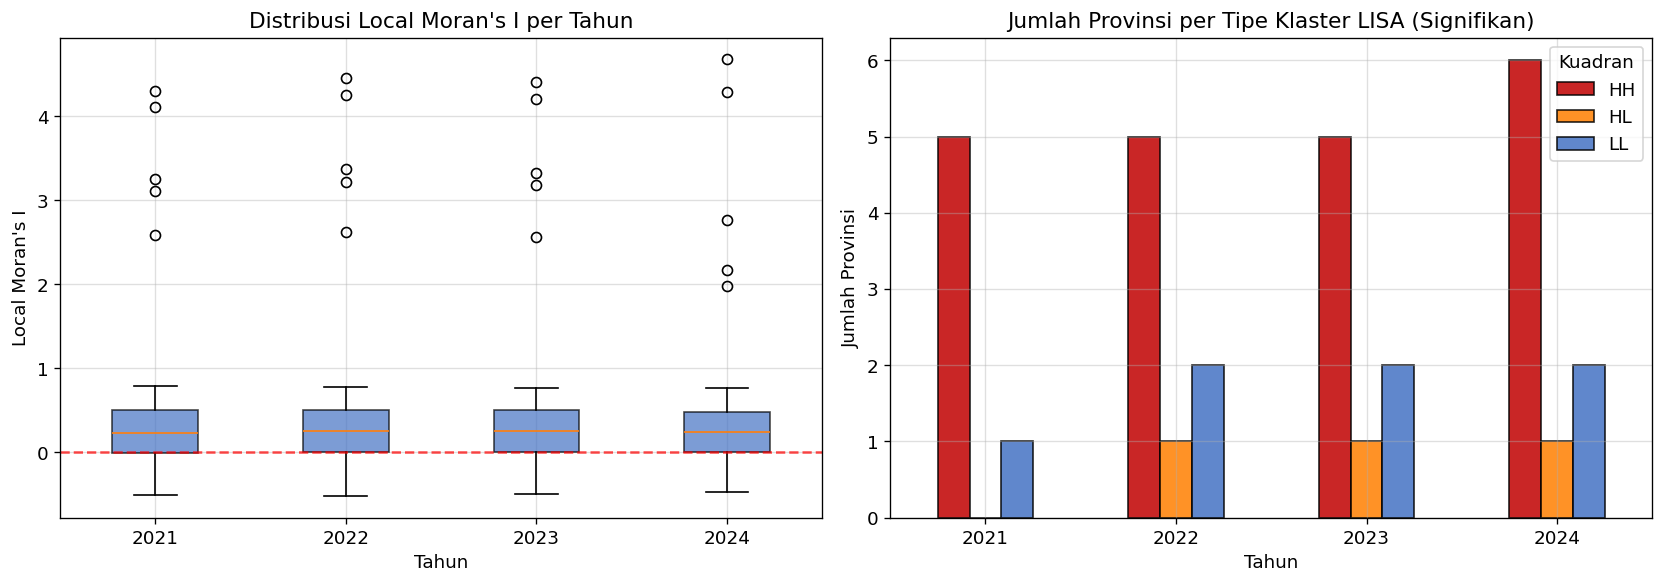

In [23]:
# Plot distribusi Local Moran's I value per tahun
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot local I per tahun
data_local_i = [df_lisa[df_lisa['tahun'] == t]['local_moran_i'].values
                for t in sorted(df_lisa['tahun'].unique())]
axes[0].boxplot(data_local_i, labels=sorted(df_lisa['tahun'].unique()),
                patch_artist=True, boxprops=dict(facecolor='#4472C4', alpha=0.7))
axes[0].axhline(0, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Distribusi Local Moran\'s I per Tahun')
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel("Local Moran's I")
axes[0].grid(alpha=0.4)

# Jumlah klaster signifikan per tahun
count_klaster = df_lisa[df_lisa['signifikan']].groupby(['tahun', 'kuadran']).size().unstack(fill_value=0)
count_klaster.plot(kind='bar', ax=axes[1],
                   color=[LISA_COLORS.get(c, 'gray') for c in count_klaster.columns],
                   alpha=0.85, edgecolor='black')
axes[1].set_title('Jumlah Provinsi per Tipe Klaster LISA (Signifikan)')
axes[1].set_xlabel('Tahun')
axes[1].set_ylabel('Jumlah Provinsi')
axes[1].legend(title='Kuadran')
axes[1].grid(alpha=0.4)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('plot_lisa_distribusi.png', bbox_inches='tight')
plt.show()

## 7. Simpan Output CSV

In [24]:
# Output 1: Global Moran's I per tahun
df_global.to_csv('output_global_morans_i.csv', index=False)
print('Disimpan: output_global_morans_i.csv')
print(df_global.to_string(index=False))

print()

# Output 2: LISA hasil lengkap per provinsi per tahun
df_lisa_out = df_lisa[[
    'tahun', 'provinsi', 'kemiskinan_pct',
    'local_moran_i', 'p_value', 'kuadran', 'signifikan', 'lon', 'lat'
]].sort_values(['tahun', 'provinsi'])

df_lisa_out.to_csv('output_lisa_results.csv', index=False)
print('Disimpan: output_lisa_results.csv')
print(df_lisa_out.head(20).to_string(index=False))

print(f'\nTotal baris output LISA: {len(df_lisa_out)}')
print(f'Kolom: {df_lisa_out.columns.tolist()}')

Disimpan: output_global_morans_i.csv
 tahun  n_provinsi  moran_i  expected_i  z_score      p_value  p_sim  signifikan
  2021          37 0.640870   -0.027778 7.443273 9.822050e-14  0.001        True
  2022          38 0.640874   -0.027027 7.544859 4.527765e-14  0.001        True
  2023          38 0.638448   -0.027027 7.517463 5.584921e-14  0.001        True
  2024          38 0.578220   -0.027027 6.837095 8.081490e-12  0.001        True

Disimpan: output_lisa_results.csv
 tahun                  provinsi  kemiskinan_pct  local_moran_i  p_value kuadran  signifikan     lon    lat
  2021                      BALI           4.165       0.227158    0.325      NS       False 115.188 -8.409
  2021                    BANTEN           6.180       0.395553    0.105      NS       False 106.064 -6.406
  2021                  BENGKULU          13.870      -0.167235    0.153      NS       False 102.346 -3.800
  2021             DI YOGYAKARTA          11.600      -0.013741    0.109      NS       Fals

In [25]:
print('RINGKASAN ANALISIS SPATIAL AUTOCORRELATION')
print()
print('GLOBAL MORAN\'S I:')
for _, row in df_global.iterrows():
    sig = 'SIGNIFIKAN' if row['signifikan'] else 'tidak signifikan'
    print(f"  {int(row['tahun'])}: I = {row['moran_i']:.4f}, "
          f"z = {row['z_score']:.4f}, p = {row['p_sim']:.4f} [{sig}]")

print()
print('LISA KLASTER SIGNIFIKAN (p<0.05):')
for tahun in sorted(df_lisa['tahun'].unique()):
    sub = df_lisa[(df_lisa['tahun'] == tahun) & (df_lisa['signifikan'])]
    hh = sub[sub['kuadran'] == 'HH']['provinsi'].tolist()
    ll = sub[sub['kuadran'] == 'LL']['provinsi'].tolist()
    hl = sub[sub['kuadran'] == 'HL']['provinsi'].tolist()
    lh = sub[sub['kuadran'] == 'LH']['provinsi'].tolist()
    print(f'  {tahun}:')
    if hh: print(f'    HH (hotspot): {hh}')
    if ll: print(f'    LL (coldspot): {ll}')
    if hl: print(f'    HL (outlier tinggi): {hl}')
    if lh: print(f'    LH (outlier rendah): {lh}')
    if not (hh or ll or hl or lh): print('    Tidak ada klaster signifikan')

print()
print('Output CSV:')
print('  1. output_global_morans_i.csv  -> Global Moran\'s I per tahun')
print('  2. output_lisa_results.csv     -> LISA per provinsi per tahun')

RINGKASAN ANALISIS SPATIAL AUTOCORRELATION

GLOBAL MORAN'S I:
  2021: I = 0.6409, z = 7.4433, p = 0.0010 [SIGNIFIKAN]
  2022: I = 0.6409, z = 7.5449, p = 0.0010 [SIGNIFIKAN]
  2023: I = 0.6384, z = 7.5175, p = 0.0010 [SIGNIFIKAN]
  2024: I = 0.5782, z = 6.8371, p = 0.0010 [SIGNIFIKAN]

LISA KLASTER SIGNIFIKAN (p<0.05):
  2021:
    HH (hotspot): ['PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']
    LL (coldspot): ['KALIMANTAN TENGAH']
  2022:
    HH (hotspot): ['PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']
    LL (coldspot): ['KEPULAUAN RIAU', 'KALIMANTAN TENGAH']
    HL (outlier tinggi): ['ACEH']
  2023:
    HH (hotspot): ['PAPUA BARAT', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']
    LL (coldspot): ['KEPULAUAN RIAU', 'KALIMANTAN TENGAH']
    HL (outlier tinggi): ['ACEH']
  2024:
    HH (hotspot): ['PAPUA BARAT', 'PAPUA BARAT DAYA', 'PAPUA', 'PAPUA SELATAN', 'PAPUA TENGAH', 'PAPUA PEGUNUNGAN']
    LL (coldspot

In [26]:
import zipfile

files_to_zip = [
    "data_bps_datmin.csv",
    "output_global_morans_i.csv",
    "output_lisa_results.csv",
    "plot_distribusi_kemiskinan.png",
    "plot_konektivitas_spasial.png",
    "plot_lisa_distribusi.png",
    "plot_lisa_konsistensi.png",
    "plot_lisa_map.png",
    "plot_moran_scatter.png",
    "plot_moran_trend.png"
]

with zipfile.ZipFile("hasil_output.zip", "w") as zipf:
    for file in files_to_zip:
        zipf.write(file)

print("ZIP selesai dibuat!")

ZIP selesai dibuat!


In [27]:
from google.colab import files
files.download("hasil_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>